#RAG Implementation 

In [2]:
#load the API

import os 
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(usecwd=True), override=True)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print("API Key Loaded:", os.getenv("GROQ_API_KEY")[:10] if os.getenv("GROQ_API_KEY") else "FAILED TO LOAD")

#Test the API KEY
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI #alternative 

llm_model = ChatGroq(model ="llama-3.3-70b-versatile" )
print(llm_model.invoke("hello, tell me about yourself in few words").content)


API Key Loaded: gsk_8yEZ0T


f:\MLwithpython\LLM_2026\llm_2026_env\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


I'm an AI assistant, here to help and provide information.


In [3]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

C:\Users\rupak\AppData\Local\Temp\ipykernel_12256\150486136.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


In [7]:
#Load Multiple pdf
from langchain_community.document_loaders import PyMuPDFLoader
loader = PyMuPDFLoader("../bootcamp\sample_docs\iphone_glass_repair.pdf")
documents = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=512, chunk_overlap=64,separators=["\n\n", "\n", ".", " ", ""])
texts = text_splitter.split_documents(documents)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\rupak\AppData\Local\Temp\ipykernel_12256\3892068910.py:3: SyntaxWarning: invalid escape sequence '\s'
  loader = PyMuPDFLoader("../bootcamp\sample_docs\iphone_glass_repair.pdf")


In [ ]:
################################################
############ CREATE Vector Store ###############
################################################


#----------- Load the Embedding model ---------------------
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Fast & lightweight model (Highly recommended for testing setup)
model_name = "sentence-transformers/all-MiniLM-L6-v2"
model_kwargs = {"device": "cpu"}
encode_kwargs = {"normalize_embeddings": False}

print(f"Initializing {model_name}...")
print("If this is the first run, downloading files may take a moment...")

embeddings = HuggingFaceEmbeddings(model_name=model_name,model_kwargs=model_kwargs,encode_kwargs=encode_kwargs)

Initializing sentence-transformers/all-MiniLM-L6-v2...
If this is the first run, downloading files may take a moment...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3140.75it/s]


In [16]:

#-------------Create Vector Store--------------------------

# Use FAISS vector DB
#from langchainvectorstores.faiss import FAISS
from langchain_community.vectorstores import FAISS
vc_db = FAISS.from_documents(texts, embeddings)
vc_db.save_local(r"..\vectordb\faiss_index")
vc_db = FAISS.load_local(r"..\vectordb\faiss_index", embeddings,allow_dangerous_deserialization=True)


In [ ]:

#Initialize the retrievaer
# retriever = vectordb.as_retriever(search_kwargs={"k": 3})
#retriever = vc_db.as_retriever()


In [20]:

from langchain_core.prompts import ChatPromptTemplate

# RAG Prompt
rag_prompt = ChatPromptTemplate.from_template("""
You are a helpful AI assistant.

Answer the question using only the information provided
in the context.

If the answer is not available in the context, say:
"I don't know based on the provided documents."

Context:
{context}

Question:
{question}

Answer:
""")


def rag(question: str):

    # Step 1: Retrieve relevant documents
    documents = retriever.invoke(question)

    # Step 2: Convert documents into context
    context = "\n\n".join(
        doc.page_content
        for doc in documents
    )

    # Step 3: Create the prompt
    prompt = rag_prompt.invoke({
        "context": context,
        "question": question
    })

    # Step 4: Call the LLM
    response = llm_model.invoke(prompt)

    return response.content
        #{"answer": response.content,
        #"documents": documents}


# Test
question = "What is the main topic of the documents?"

answer = rag(question)

print("Answer:")
print(answer)

Answer:
The main topic of the documents appears to be the repair or replacement of a broken iPhone back glass, specifically the steps involved in preparing the surface and applying a back protective cover.


In [32]:
#with meta data filtering

def retrieve_documents(question, metadata_filter=None):

    if metadata_filter:
        retriever = vc_db.as_retriever(
            search_kwargs={
                "k": 5,
                "filter": metadata_filter
            })
    else:
        retriever = vc_db.as_retriever(
            search_kwargs={"k": 5})
    return retriever.invoke(question)


def rag(question, metadata_filter=None):

    documents = retrieve_documents(
        question,
        metadata_filter
    )

    context = "\n\n".join(
        doc.page_content
        for doc in documents
    )

    prompt = rag_prompt.invoke({
        "context": context,
        "question": question
    })

    response = llm_model.invoke(prompt)

    return {
        "answer": response.content,
        "documents": documents
    }



In [ ]:
# Test
question = "What is the main topic of the documents?"

answer = rag(question)
print(answer)

Answer:
{'answer': 'The main topic of the documents appears to be the repair of a broken iPhone back glass.', 'documents': [Document(id='5daede5f-6407-4345-b756-1ab3b68790da', metadata={'producer': 'Skia/PDF m151', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36', 'creationdate': '2026-08-13T16:08:35+00:00', 'source': '../bootcamp\\sample_docs\\iphone_glass_repair.pdf', 'file_path': '../bootcamp\\sample_docs\\iphone_glass_repair.pdf', 'total_pages': 5, 'format': 'PDF 1.4', 'title': 'iPhone Broken Glass Safety - Apple Support (IN)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-08-13T16:08:35+00:00', 'trapped': '', 'modDate': "D:20260813160835+00'00'", 'creationDate': "D:20260813160835+00'00'", 'page': 3}, page_content='7. Remove the sanding cover and vacuum your workspace and the iPhone again. Wipe the back glass with an ethanol\nwipe or IPA wipe.\n8. Ensure that the sanded area appears shiny. I

In [39]:
answer["documents"]
answer["answer"]


'The main topic of the documents appears to be the repair of a broken iPhone back glass.'

In [ ]:
#Use structed output to understand the user intent

# ============================================================
# 1. IMPORTS
# ============================================================

from typing import Optional
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

# ============================================================
# 3. DEFINE METADATA SCHEMA
# ============================================================

class MetadataFilter(BaseModel):

    department: Optional[str] = Field(
        default=None,
        description=(
            "Department mentioned in the user's question. "
            "Examples: Finance, HR, Sales, IT"
        )
    )

    year: Optional[int] = Field(
        default=None,
        description=(
            "Year mentioned in the user's question. "
            "Example: 2025"
        )
    )

    document_type: Optional[str] = Field(
        default=None,
        description=(
            "Type of document requested by the user. "
            "Examples: policy, report, invoice, annual_report"
        )
    )


# ============================================================
# 4. CREATE STRUCTURED OUTPUT LLM
# ============================================================

filter_llm = llm_model.with_structured_output(
    MetadataFilter
)


# ============================================================
# 5. EXTRACT METADATA FROM USER QUESTION
# ============================================================

def extract_metadata_filter(question: str):

    extraction_prompt = f"""
You are a metadata extraction system.

Analyze the user's question and identify any metadata
filters explicitly or clearly implied by the question.

Available metadata fields:

1. department
2. year
3. document_type

Rules:

- Extract only information that is relevant to these fields.
- If a field is not mentioned, return None.
- Do NOT invent metadata.
- Return the department exactly as understood from the question.
- Return year as an integer.

Examples:

Question:
"What was the Finance revenue in 2025?"

Output:
department = Finance
year = 2025

Question:
"Show me the HR policy from 2024"

Output:
department = HR
year = 2024
document_type = policy

Question:
"What is the revenue?"

Output:
department = None
year = None
document_type = None

User Question:
{question}
"""

    result = filter_llm.invoke(extraction_prompt)

    # ----------------------------------------
    # Build dictionary
    # ----------------------------------------

    metadata_filter = {}

    if result.department is not None:
        metadata_filter["department"] = result.department

    if result.year is not None:
        metadata_filter["year"] = result.year

    if result.document_type is not None:
        metadata_filter["document_type"] = result.document_type

    return metadata_filter


# ============================================================
# 6. RETRIEVE DOCUMENTS FROM FAISS
# ============================================================

def retrieve_documents(
    question: str,
    metadata_filter: dict | None = None,
    k: int = 5
):

    # ----------------------------------------
    # Normal retrieval
    # ----------------------------------------

    if not metadata_filter:

        retriever = vc_db.as_retriever(
            search_kwargs={"k": k })

    # ----------------------------------------
    # Metadata filtered retrieval
    # ----------------------------------------

    else:

        retriever = vc_db.as_retriever(
            search_kwargs={
                "k": k, "filter": metadata_filter})

    # ----------------------------------------
    # Invoke retriever
    # ----------------------------------------

    documents = retriever.invoke(
        question
    )

    return documents


# ============================================================
# 7. RAG PROMPT
# ============================================================

rag_prompt = ChatPromptTemplate.from_template("""
You are a helpful AI assistant.

Answer the user's question using ONLY the provided context.

Rules:

1. Do not make up information.
2. If the answer is not available in the context,
   say "I don't know based on the provided documents."
3. Give a concise and accurate answer.
4. Use the retrieved documents as the source of truth.

Context:
{context}

Question:
{question}

Answer:
""")


# ============================================================
# 8. MAIN RAG FUNCTION
# ============================================================

def rag(question: str):

    # ----------------------------------------
    # STEP 1
    # Understand user intent and extract
    # metadata filters
    # ----------------------------------------

    metadata_filter = extract_metadata_filter(
        question
    )

    print("\nDetected Metadata Filter:")
    print(metadata_filter)


    # ----------------------------------------
    # STEP 2
    # Retrieve documents
    # ----------------------------------------

    documents = retrieve_documents(
        question=question,
        metadata_filter=metadata_filter,
        k=5
    )


    # ----------------------------------------
    # STEP 3
    # Build context
    # ----------------------------------------

    context = "\n\n".join(

        f"""
Source: {doc.metadata.get("source", "Unknown")}
Page: {doc.metadata.get("page", "Unknown")}

{doc.page_content}
"""
        for doc in documents
    )


    # ----------------------------------------
    # STEP 4
    # Create RAG prompt
    # ----------------------------------------

    prompt = rag_prompt.invoke({

        "context": context,

        "question": question

    })


    # ----------------------------------------
    # STEP 5
    # Call LLM
    # ----------------------------------------

    response = llm_model.invoke(
        prompt
    )


    # ----------------------------------------
    # STEP 6
    # Return everything
    # ----------------------------------------

    return {

        "answer": response.content,

        "documents": documents,

        "metadata_filter": metadata_filter

    }


# ============================================================
# 9. TEST 1 - QUESTION WITH METADATA
# ============================================================

question = "What was the Finance revenue in 2025?"

result = rag(question)


print("\n====================================")
print("ANSWER")
print("====================================")

print(result["answer"])


print("\n====================================")
print("METADATA FILTER")
print("====================================")

print(result["metadata_filter"])


print("\n====================================")
print("RETRIEVED DOCUMENTS")
print("====================================")

for i, doc in enumerate(
    result["documents"],
    1
):

    print(f"\n----------- DOCUMENT {i} -----------")

    print("\nMetadata:")
    print(doc.metadata)

    print("\nContent:")
    print(doc.page_content[:500])


Detected Metadata Filter:
{'department': 'Finance', 'year': 2025}

ANSWER
I don't know based on the provided documents.

METADATA FILTER
{'department': 'Finance', 'year': 2025}

RETRIEVED DOCUMENTS


In [ ]:

# ============================================================
# 9. TEST 2 - QUESTION WITH METADATA
# ============================================================

question = "when the document is dated?"

result = rag(question)


print("\n====================================")
print("ANSWER")
print("====================================")

print(result["answer"])


print("\n====================================")
print("METADATA FILTER")
print("====================================")

print(result["metadata_filter"])


print("\n====================================")
print("RETRIEVED DOCUMENTS")
print("====================================")

for i, doc in enumerate(
    result["documents"], 1):

    print(f"\n----------- DOCUMENT {i} -----------")

    print("\nMetadata:")
    print(doc.metadata)

    print("\nContent:")
    print(doc.page_content[:500])


Detected Metadata Filter:
{}

ANSWER
The document was published on February 28, 2025, and copyrighted in 2026.

METADATA FILTER
{}

RETRIEVED DOCUMENTS

----------- DOCUMENT 1 -----------

Metadata:
{'producer': 'Skia/PDF m151', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36', 'creationdate': '2026-08-13T16:08:35+00:00', 'source': '../bootcamp\\sample_docs\\iphone_glass_repair.pdf', 'file_path': '../bootcamp\\sample_docs\\iphone_glass_repair.pdf', 'total_pages': 5, 'format': 'PDF 1.4', 'title': 'iPhone Broken Glass Safety - Apple Support (IN)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-08-13T16:08:35+00:00', 'trapped': '', 'modDate': "D:20260813160835+00'00'", 'creationDate': "D:20260813160835+00'00'", 'page': 3}

Content:
7. Remove the sanding cover and vacuum your workspace and the iPhone again. Wipe the back glass with an ethanol
wipe or IPA wipe.
8. Ensure that the sanded area appears 

In [43]:
result['answer']

'The document was published on February 28, 2025, and copyrighted in 2026.'

## LEVEL 2 RAG 

In [44]:
# ============================================================
# 1. IMPORTS
# ============================================================

from typing import Optional, List
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate


# ============================================================
# 2. CONFIGURATION
# ============================================================

TOP_K_RETRIEVAL = 10
TOP_K_FINAL = 5

VALID_DEPARTMENTS = {
    "Finance",
    "HR",
    "Sales",
    "IT",
    "Marketing"
}

VALID_DOCUMENT_TYPES = {
    "report",
    "policy",
    "invoice",
    "annual_report"
}

VALID_YEARS = {
    2023,
    2024,
    2025,
    2026
}


# ============================================================
# 3. STRUCTURED OUTPUT
#    Understand user intent + rewrite query + metadata
# ============================================================

class SearchIntent(BaseModel):

    search_query: str = Field(
        description=(
            "A concise semantic search query optimized "
            "for document retrieval."
        )
    )

    department: Optional[str] = Field(
        default=None,
        description="Department explicitly mentioned by the user."
    )

    year: Optional[int] = Field(
        default=None,
        description="Year explicitly mentioned by the user."
    )

    document_type: Optional[str] = Field(
        default=None,
        description="Document type requested by the user."
    )


intent_llm = llm_model.with_structured_output( SearchIntent)


# ============================================================
# 4. ANALYZE USER QUERY
# ============================================================

def analyze_query(question: str) -> SearchIntent:

    prompt = f"""
You are a search-intent extraction system for a RAG application.

Analyze the user's question.

Your job is to:

1. Rewrite the question into a concise semantic search query.
2. Extract metadata filters ONLY when the user explicitly
   mentions or clearly specifies them.

Available metadata:

- department
- year
- document_type

Rules:

- Do not invent metadata.
- If metadata is not mentioned, return None.
- Preserve the user's actual intent.
- The search_query should contain the important semantic
  concepts needed for document retrieval.

Examples:

User:
"What was the Finance revenue in 2025?"

Return:

search_query = "Finance revenue 2025"
department = "Finance"
year = 2025
document_type = None


User:
"Show me the HR policy from 2024"

Return:

search_query = "HR policy 2024"
department = "HR"
year = 2024
document_type = "policy"


User:
"Explain the revenue numbers"

Return:

search_query = "revenue numbers"
department = None
year = None
document_type = None


User question:

{question}
"""

    return intent_llm.invoke(prompt)


# ============================================================
# 5. VALIDATE METADATA
# ============================================================

def validate_metadata(intent: SearchIntent):

    metadata_filter = {}

    # -----------------------------------------
    # Department
    # -----------------------------------------

    if intent.department:

        if intent.department in VALID_DEPARTMENTS:
            metadata_filter["department"] = (intent.department)

    # -----------------------------------------
    # Year
    # -----------------------------------------

    if intent.year:

        if intent.year in VALID_YEARS:
            metadata_filter["year"] = intent.year

    # -----------------------------------------
    # Document type
    # -----------------------------------------

    if intent.document_type:

        if intent.document_type in VALID_DOCUMENT_TYPES:
            metadata_filter["document_type"] = (
                intent.document_type
            )

    return metadata_filter


# ============================================================
# 6. RETRIEVE FROM FAISS
# ============================================================

def retrieve_documents(
    query: str,
    metadata_filter: Optional[dict] = None,
    k: int = TOP_K_RETRIEVAL
):

    search_kwargs = { "k": k}

    # -----------------------------------------
    # Apply metadata filter
    # -----------------------------------------

    if metadata_filter:
        search_kwargs["filter"] = metadata_filter

    # -----------------------------------------
    # Create retriever
    # -----------------------------------------

    retriever = vc_db.as_retriever(
        search_kwargs=search_kwargs
    )

    # -----------------------------------------
    # Retrieve
    # -----------------------------------------

    documents = retriever.invoke(query)

    return documents


# ============================================================
# 7. FALLBACK RETRIEVAL
# ============================================================

def retrieve_with_fallback(
    query: str,
    metadata_filter: dict
):

    # -----------------------------------------
    # First attempt:
    # Metadata filtered search
    # -----------------------------------------

    documents = retrieve_documents(
        query=query,
        metadata_filter=metadata_filter,
        k=TOP_K_RETRIEVAL
    )

    # -----------------------------------------
    # If documents found
    # -----------------------------------------

    if documents:
        return documents, True

    # -----------------------------------------
    # Fallback:
    # Semantic search without metadata
    # -----------------------------------------

    documents = retrieve_documents(
        query=query,
        metadata_filter=None,
        k=TOP_K_RETRIEVAL
    )

    return documents, False


# ============================================================
# 8. RERANKING
# ============================================================

def rerank_documents(
    question: str,
    documents: List,
    top_k: int = TOP_K_FINAL
):

    # ------------------------------------------------
    # Simple LLM-based reranking
    #
    # This is useful for demonstrating the concept.
    # For production, consider a dedicated reranker
    # such as a cross-encoder.
    # ------------------------------------------------

    if not documents:
        return []

    scored_documents = []

    for doc in documents:

        prompt = f"""
You are a document relevance evaluator.

Determine how relevant the following document is
to the user's question.

Give a relevance score from 0 to 10.

10 = directly answers the question
7-9 = highly relevant
4-6 = somewhat relevant
1-3 = weakly relevant
0 = irrelevant

Question:
{question}

Document:
{doc.page_content[:3000]}

Return ONLY the number.
"""

        response = llm_model.invoke(prompt)

        try:
            score = float(
                response.content.strip()
            )

        except ValueError:
            score = 0

        scored_documents.append(
            (score, doc)
        )

    # -----------------------------------------
    # Sort by relevance
    # -----------------------------------------

    scored_documents.sort(
        key=lambda x: x[0],
        reverse=True
    )

    # -----------------------------------------
    # Return Top N
    # -----------------------------------------

    return [
        doc
        for score, doc
        in scored_documents[:top_k]
    ]


# ============================================================
# 9. RAG PROMPT
# ============================================================

rag_prompt = ChatPromptTemplate.from_template("""
You are an enterprise RAG assistant.

Answer the user's question using ONLY the provided
documents.

Rules:

1. Do not hallucinate.
2. If the answer cannot be found in the documents,
   say:
   "I don't know based on the provided documents."
3. Be concise but informative.
4. Cite the source when possible.
5. Do not use outside knowledge.

Retrieved Context:

{context}

User Question:

{question}

Answer:
""")


# ============================================================
# 10. BUILD CONTEXT
# ============================================================

def build_context(documents):

    context_parts = []

    for i, doc in enumerate(
        documents, 1
    ):

        source = doc.metadata.get(
            "source",
            "Unknown"
        )

        page = doc.metadata.get(
            "page",
            "Unknown"
        )

        department = doc.metadata.get(
            "department",
            "Unknown"
        )

        year = doc.metadata.get(
            "year",
            "Unknown"
        )

        context_parts.append(
            f"""
DOCUMENT {i}

Source: {source}
Page: {page}
Department: {department}
Year: {year}

Content:
{doc.page_content}
"""
        )

    return "\n\n".join(
        context_parts
    )


# ============================================================
# 11. MAIN RAG PIPELINE
# ============================================================

def rag(question: str):

    # =========================================
    # STEP 1
    # Understand user intent
    # =========================================

    intent = analyze_query(
        question
    )

    print("\n==============================")
    print("SEARCH INTENT")
    print("==============================")

    print(
        "Search Query:",
        intent.search_query
    )

    print(
        "Department:",
        intent.department
    )

    print(
        "Year:",
        intent.year
    )

    print(
        "Document Type:",
        intent.document_type
    )


    # =========================================
    # STEP 2
    # Validate metadata
    # =========================================

    metadata_filter = validate_metadata(
        intent
    )

    print("\n==============================")
    print("METADATA FILTER")
    print("==============================")

    print(metadata_filter)


    # =========================================
    # STEP 3
    # Retrieve
    # =========================================

    documents, used_metadata_filter = (
        retrieve_with_fallback(
            query=intent.search_query,
            metadata_filter=metadata_filter
        )
    )


    print("\n==============================")
    print("RETRIEVAL")
    print("==============================")

    print(
        "Documents retrieved:",
        len(documents)
    )

    print(
        "Metadata filter used:",
        used_metadata_filter
    )


    # =========================================
    # STEP 4
    # Rerank
    # =========================================

    reranked_documents = rerank_documents(
        question=question,
        documents=documents,
        top_k=TOP_K_FINAL
    )


    print("\n==============================")
    print("RERANKING")
    print("==============================")

    print(
        "Final documents:",
        len(reranked_documents)
    )


    # =========================================
    # STEP 5
    # Build context
    # =========================================

    context = build_context(
        reranked_documents
    )


    # =========================================
    # STEP 6
    # Generate prompt
    # =========================================

    prompt = rag_prompt.invoke({

        "context": context,

        "question": question

    })


    # =========================================
    # STEP 7
    # Generate answer
    # =========================================

    response = llm_model.invoke(
        prompt
    )


    # =========================================
    # STEP 8
    # Return result
    # =========================================

    return {

        "answer": response.content,

        "search_query": intent.search_query,

        "metadata_filter": metadata_filter,

        "metadata_filter_used": (
            used_metadata_filter
        ),

        "documents": reranked_documents

    }


# ============================================================
# 12. TEST
# ============================================================

question = (
    "What was the Finance revenue "
    "in 2025?"
)

result = rag(
    question
)


# ============================================================
# 13. PRINT ANSWER
# ============================================================

print("\n\n================================")
print("FINAL ANSWER")
print("================================")

print(
    result["answer"]
)


# ============================================================
# 14. PRINT SOURCES
# ============================================================

print("\n================================")
print("SOURCES")
print("================================")

for i, doc in enumerate(
    result["documents"],
    1
):

    print(
        f"\n--- SOURCE {i} ---"
    )

    print(
        "Metadata:",
        doc.metadata
    )

    print(
        "Content:",
        doc.page_content[:500]
    )


SEARCH INTENT
Search Query: Finance revenue 2025
Department: Finance
Year: 2025
Document Type: None

METADATA FILTER
{'department': 'Finance', 'year': 2025}

RETRIEVAL
Documents retrieved: 9
Metadata filter used: False

RERANKING
Final documents: 5


FINAL ANSWER
I don't know based on the provided documents.

SOURCES

--- SOURCE 1 ---
Metadata: {'producer': 'Skia/PDF m151', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36', 'creationdate': '2026-08-13T16:08:35+00:00', 'source': '../bootcamp\\sample_docs\\iphone_glass_repair.pdf', 'file_path': '../bootcamp\\sample_docs\\iphone_glass_repair.pdf', 'total_pages': 5, 'format': 'PDF 1.4', 'title': 'iPhone Broken Glass Safety - Apple Support (IN)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-08-13T16:08:35+00:00', 'trapped': '', 'modDate': "D:20260813160835+00'00'", 'creationDate': "D:20260813160835+00'00'", 'page': 4}
Content: Helpful?
Yes
 
No
If t

In [ ]:
# Fall Back Mechanism
Suppose your metadata has 
{
    "department": "finance",
    "year": "2025"
}

However, 
Finance ≠ finance
2025 (integer) ≠ "2025" (string)

So it will return null

User Question
      ↓
Extract Metadata
      ↓
Filtered Search
      ↓
Documents found?
    /       \
  YES        NO
   ↓          ↓
Answer    Remove filter
              ↓
        Semantic Search
              ↓
           Documents

IndentationError: unindent does not match any outer indentation level (<string>, line 21)

In [47]:
# ============================================================
# 1. IMPORTS
# ============================================================

from typing import Optional
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.messages import HumanMessage

# ============================================================
# 3. METADATA SCHEMA
# ============================================================

class SearchIntent(BaseModel):

    search_query: str = Field(
        description="Optimized semantic search query"
    )

    department: Optional[str] = Field(
        default=None
    )

    year: Optional[int] = Field(
        default=None
    )

    document_type: Optional[str] = Field(
        default=None
    )


# ============================================================
# 4. INTENT MODEL
# ============================================================

intent_llm = llm_model.with_structured_output(SearchIntent)


# ============================================================
# 5. METADATA EXTRACTION
# ============================================================

def analyze_query(question: str):

    prompt = f"""
You are a search intent analyzer.

Analyze the user's question.

Extract:

1. Optimized semantic search query
2. Department
3. Year
4. Document type

Available metadata:

department:
Finance, HR, Sales, IT, Marketing

document_type:
report, policy, invoice, annual_report

Rules:

- Do not invent metadata.
- If metadata is not present, return None.
- Rewrite the question into a useful search query.

User question:

{question}
"""

    return intent_llm.invoke(prompt)


# ============================================================
# 6. METADATA VALIDATION
# ============================================================

VALID_DEPARTMENTS = {
    "Finance",
    "HR",
    "Sales",
    "IT",
    "Marketing"}

VALID_DOCUMENT_TYPES = {
    "report",
    "policy",
    "invoice",
    "annual_report"}

VALID_YEARS = {
    2023,
    2024,
    2025,
    2026}


def create_metadata_filter(intent):

    metadata_filter = {}

    if (intent.department and intent.department in VALID_DEPARTMENTS):
        metadata_filter["department"] = (intent.department)

    if (intent.year and intent.year in VALID_YEARS ):
        metadata_filter["year"] = intent.year

    if (intent.document_type
        and intent.document_type in VALID_DOCUMENT_TYPES):
        metadata_filter["document_type"] = (intent.document_type)

    return metadata_filter


# ============================================================
# 7. RETRIEVAL FUNCTION
# ============================================================

def retrieve_documents(
    query: str,
    metadata_filter: dict | None = None,
    k: int = 10):

    search_kwargs = {"k": k}

    if metadata_filter:
        search_kwargs["filter"] = metadata_filter

    retriever = vc_db.as_retriever(
        search_kwargs=search_kwargs)

    return retriever.invoke(query)


# ============================================================
# 8. RAG TOOL
# ============================================================

@tool
def search_documents(question: str) -> str:
    """
    Search enterprise documents using semantic search
    and metadata filtering.

    Use this tool when the user asks about information
    contained in company documents.
    """

    # ------------------------------------------
    # Analyze intent
    # ------------------------------------------

    intent = analyze_query(question)

    # ------------------------------------------
    # Create metadata filter
    # ------------------------------------------

    metadata_filter = create_metadata_filter(intent)

    # ------------------------------------------
    # Retrieve
    # ------------------------------------------

    documents = retrieve_documents(
        query=intent.search_query,
        metadata_filter=metadata_filter,
        k=10 )

    # ------------------------------------------
    # Fallback
    # ------------------------------------------

    if not documents and metadata_filter:

        documents = retrieve_documents(
            query=intent.search_query,
            metadata_filter=None,
            k=10)

    # ------------------------------------------
    # No documents
    # ------------------------------------------

    if not documents:
        return (
            "No relevant documents were found.")

    # ------------------------------------------
    # Build result
    # ------------------------------------------

    results = []

    for i, doc in enumerate(
        documents,1):

        source = doc.metadata.get(
            "source",
            "Unknown"
        )

        page = doc.metadata.get(
            "page",
            "Unknown"
        )

        department = doc.metadata.get(
            "department",
            "Unknown"
        )

        year = doc.metadata.get(
            "year",
            "Unknown"
        )

        results.append(
            f"""
DOCUMENT {i}

Source: {source}
Page: {page}
Department: {department}
Year: {year}

Content:
{doc.page_content}
"""
        )

    return "\n\n".join(results)


# ============================================================
# 9. AGENT SYSTEM PROMPT
# ============================================================

SYSTEM_PROMPT = """
You are an enterprise AI assistant.

You can answer questions using enterprise documents.

You have access to the following tool:

search_documents

Use search_documents when:

- The user asks about company information.
- The user asks about reports.
- The user asks about policies.
- The user asks about financial information.
- The user asks about information that may exist
  inside enterprise documents.

Do NOT use the document search tool for simple
conversational questions that you can answer directly.

When using retrieved documents:

1. Answer only from the retrieved information.
2. Do not hallucinate.
3. Mention the source when possible.
4. If documents do not contain the answer,
   clearly say that the information was not found.
5. Do not expose internal reasoning.
"""


# ============================================================
# 10. CREATE AGENT
# ============================================================

agent = create_agent(
    model=llm_model,
    tools=[search_documents ],
    system_prompt=SYSTEM_PROMPT)


# ============================================================
# 11. TEST AGENT
# ============================================================

question = (
    "When the document is written "
    "in 2025?"
)

response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content=question
            )
        ]
    }
)


# ============================================================
# 12. PRINT RESPONSE
# ============================================================

print("\n==============================")
print("FINAL ANSWER")
print("==============================")

response["messages"][-1].pretty_print()


FINAL ANSWER
================================== Ai Message ==================================

The document was written on February 28, 2025, according to the information found in Document 4.


# Level 3 Agentic RAG without tool(deterministic approach) 
--- as tools might hallucination

In [48]:
# ============================================================
# 1. IMPORTS
# ============================================================

from typing import Optional, List, TypedDict
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END

# ============================================================
# 3. CONFIGURATION
# ============================================================

TOP_K_RETRIEVAL = 10
TOP_K_FINAL = 5
MAX_REWRITE_ATTEMPTS = 1


# ============================================================
# 4. VALID METADATA
# ============================================================

VALID_DEPARTMENTS = {
    "Finance",
    "HR",
    "Sales",
    "IT",
    "Marketing"}

VALID_DOCUMENT_TYPES = {
    "report",
    "policy",
    "invoice",
    "annual_report"}

VALID_YEARS = {
    2023,
    2024,
    2025,
    2026}


# ============================================================
# 5. SEARCH INTENT SCHEMA
# ============================================================

class SearchIntent(BaseModel):

    search_query: str = Field(
        description=(
            "Optimized semantic search query for "
            "retrieving relevant documents."
        )
    )

    department: Optional[str] = Field(
        default=None,
        description="Department mentioned by the user."
    )

    year: Optional[int] = Field(
        default=None,
        description="Year mentioned by the user."
    )

    document_type: Optional[str] = Field(
        default=None,
        description="Document type mentioned by the user."
    )


# ============================================================
# 6. STRUCTURED OUTPUT LLM
# ============================================================

intent_llm = llm_model.with_structured_output(SearchIntent)


# ============================================================
# 7. LANGGRAPH STATE
# ============================================================

class RAGState(TypedDict, total=False):

    question: str
    search_query: str
    metadata_filter: dict
    documents: List
    reranked_documents: List
    context: str
    answer: str
    sources: List
    rewrite_count: int
    retrieval_success: bool


# ============================================================
# 8. NODE 1
# ANALYZE USER QUESTION
# ============================================================

def analyze_query(state: RAGState):

    question = state["question"]

    prompt = f"""
You are a search-intent analyzer for an enterprise RAG system.

Analyze the user's question.

Extract:

1. A concise semantic search query.
2. Department.
3. Year.
4. Document type.

Allowed departments:

Finance
HR
Sales
IT
Marketing

Allowed document types:

report
policy
invoice
annual_report

Rules:

- Do not invent metadata.
- If metadata is not present, return None.
- Preserve the actual intent of the question.
- Do not answer the question.
- Only analyze the search intent.

Examples:

Question:
"What was the Finance revenue in 2025?"

search_query:
Finance revenue 2025

department:
Finance

year:
2025

document_type:
None


Question:
"Show me the HR policy from 2024"

search_query:
HR policy 2024

department:
HR

year:
2024

document_type:
policy


Question:
"What is the main topic of the documents?"

search_query:
main topic of documents

department:
None

year:
None

document_type:
None


User question:

{question}
"""

    intent = intent_llm.invoke(prompt )

    return {
        "search_query": intent.search_query,

        "metadata_filter": {
            "department": intent.department,
            "year": intent.year,
            "document_type": intent.document_type}
    }


# ============================================================
# 9. NODE 2
# VALIDATE METADATA
# ============================================================

def validate_metadata(state: RAGState):

    raw_filter = state.get(
        "metadata_filter",
        {}
    )

    metadata_filter = {}

    department = raw_filter.get(
        "department"
    )

    year = raw_filter.get(
        "year"
    )

    document_type = raw_filter.get(
        "document_type"
    )


    # ------------------------------------------
    # Validate department
    # ------------------------------------------

    if (
        department and department in VALID_DEPARTMENTS
    ):

        metadata_filter[
            "department"
        ] = department


    # ------------------------------------------
    # Validate year
    # ------------------------------------------

    if (
        year
        and year in VALID_YEARS
    ):

        metadata_filter[
            "year"
        ] = year


    # ------------------------------------------
    # Validate document type
    # ------------------------------------------

    if (document_type and document_type in VALID_DOCUMENT_TYPES):
        metadata_filter[ "document_type" ] = document_type

    return {"metadata_filter": metadata_filter }


# ============================================================
# 10. NODE 3
# RETRIEVE DOCUMENTS
# ============================================================

def retrieve_documents(state: RAGState):

    query = state["search_query" ]

    metadata_filter = state.get( "metadata_filter", {} )

    # ------------------------------------------
    # Build retriever
    # ------------------------------------------

    search_kwargs = { "k": TOP_K_RETRIEVAL}


    # ------------------------------------------
    # Add metadata filter
    # ------------------------------------------

    if metadata_filter:
        search_kwargs[ "filter"] = metadata_filter


    # ------------------------------------------
    # Create retriever
    # ------------------------------------------

    retriever = vc_db.as_retriever(
        search_kwargs=search_kwargs )


    # ------------------------------------------
    # Retrieve
    # ------------------------------------------

    documents = retriever.invoke(query )


    # ------------------------------------------
    # Determine success
    # ------------------------------------------

    retrieval_success = (len(documents) > 0 )


    return {
        "documents": documents,
        "retrieval_success": retrieval_success
    }


# ============================================================
# 11. NODE 4
# CHECK RETRIEVAL
# ============================================================

def check_retrieval(state: RAGState):

    documents = state.get("documents",[] )

    rewrite_count = state.get("rewrite_count",0 )


    # ------------------------------------------
    # Documents found
    # ------------------------------------------

    if documents:
        return "rerank"


    # ------------------------------------------
    # No documents
    # ------------------------------------------

    if rewrite_count < MAX_REWRITE_ATTEMPTS:

        return "rewrite"


    # ------------------------------------------
    # No documents after retry
    # ------------------------------------------

    return "no_results"


# ============================================================
# 12. NODE 5
# QUERY REWRITE
# ============================================================

def rewrite_query(state: RAGState):

    question = state["question" ]

    old_query = state["search_query"]

    rewrite_prompt = f"""
Rewrite the search query to improve semantic
document retrieval.

Original user question:

{question}

Previous search query:

{old_query}

Rules:

- Preserve the user's intent.
- Do not invent facts.
- Do not add metadata that wasn't mentioned.
- Make the query concise and retrieval-friendly.

Return ONLY the rewritten query.
"""

    response = llm_model.invoke(rewrite_prompt )


    return {
        "search_query": response.content.strip(),
        "rewrite_count":
            state.get(
                "rewrite_count",0 ) + 1 }


# ============================================================
# 13. NODE 6
# RERANK DOCUMENTS
# ============================================================

def rerank_documents(state: RAGState):

    question = state[ "question"]

    documents = state[ "documents" ]

    scored_documents = []

    for doc in documents:

        rerank_prompt = f"""
You are a document relevance evaluator.

Evaluate how relevant this document is to
the user's question.

Score from 0 to 10.

10 = directly answers the question
7-9 = highly relevant
4-6 = partially relevant
1-3 = weakly relevant
0 = irrelevant

Question:

{question}

Document:

{doc.page_content[:3000]}

Return ONLY the numeric score.
"""

        response = llm_model.invoke(
            rerank_prompt )


        try:

            score = float( response.content.strip() )

        except ValueError:
            score = 0

        scored_documents.append((score, doc) )


    # ------------------------------------------
    # Sort
    # ------------------------------------------

    scored_documents.sort(
        key=lambda x: x[0],
        reverse=True )


    # ------------------------------------------
    # Top documents
    # ------------------------------------------

    final_documents = [

        doc

        for score, doc

        in scored_documents[
            :TOP_K_FINAL
        ]

    ]


    return {
        "reranked_documents":
            final_documents
    }


# ============================================================
# 14. NODE 7
# BUILD CONTEXT
# ============================================================

def build_context(state: RAGState):

    documents = state[
        "reranked_documents"
    ]

    context_parts = []


    for i, doc in enumerate(
        documents,
        1
    ):

        source = doc.metadata.get(
            "source",
            "Unknown"
        )

        page = doc.metadata.get(
            "page",
            "Unknown"
        )

        department = doc.metadata.get(
            "department",
            "Unknown"
        )

        year = doc.metadata.get(
            "year",
            "Unknown"
        )

        document_type = doc.metadata.get(
            "document_type",
            "Unknown"
        )


        context_parts.append(

            f"""
DOCUMENT {i}

Source: {source}
Page: {page}
Department: {department}
Year: {year}
Document Type: {document_type}

Content:

{doc.page_content}
"""
        )


    context = "\n\n".join(
        context_parts
    )


    return {
        "context": context
    }


# ============================================================
# 15. NODE 8
# GENERATE GROUNDED ANSWER
# ============================================================

def generate_answer(state: RAGState):

    question = state[
        "question"
    ]

    context = state[
        "context"
    ]


    prompt = f"""
You are an enterprise RAG assistant.

Answer the user's question ONLY using
the retrieved documents below.

STRICT RULES:

1. Do not use outside knowledge.
2. Do not hallucinate.
3. Do not make assumptions.
4. If the answer is not contained in the
   documents, say:

"I could not find sufficient information
in the retrieved documents."

5. Cite the source when possible.
6. Do not claim information that is not
   supported by the documents.

Retrieved Documents:

{context}

User Question:

{question}

Answer:
"""


    response = llm_model.invoke(
        prompt
    )


    return {
        "answer": response.content
    }


# ============================================================
# 16. NODE 9
# NO RESULTS
# ============================================================

def no_results(state: RAGState):

    return {
        "answer": (
            "I could not find any documents "
            "matching the requested criteria."
        )
    }


# ============================================================
# 17. BUILD LANGGRAPH
# ============================================================

builder = StateGraph(
    RAGState
)


# ============================================================
# 18. ADD NODES
# ============================================================

builder.add_node(
    "analyze_query",
    analyze_query
)

builder.add_node(
    "validate_metadata",
    validate_metadata
)

builder.add_node(
    "retrieve",
    retrieve_documents
)

builder.add_node(
    "rewrite",
    rewrite_query
)

builder.add_node(
    "rerank",
    rerank_documents
)

builder.add_node(
    "build_context",
    build_context
)

builder.add_node(
    "generate_answer",
    generate_answer
)

builder.add_node(
    "no_results",
    no_results
)


# ============================================================
# 19. DEFINE EDGES
# ============================================================

builder.add_edge(
    START,
    "analyze_query"
)

builder.add_edge(
    "analyze_query",
    "validate_metadata"
)

builder.add_edge(
    "validate_metadata",
    "retrieve"
)


# ============================================================
# 20. CONDITIONAL RETRIEVAL EDGE
# ============================================================

builder.add_conditional_edges(

    "retrieve",

    check_retrieval,

    {

        "rerank":
            "rerank",

        "rewrite":
            "rewrite",

        "no_results":
            "no_results"
    }
)


# ============================================================
# 21. REWRITE → RETRIEVE
# ============================================================

builder.add_edge(
    "rewrite",
    "retrieve"
)


# ============================================================
# 22. RERANK → CONTEXT
# ============================================================

builder.add_edge(
    "rerank",
    "build_context"
)


# ============================================================
# 23. CONTEXT → ANSWER
# ============================================================

builder.add_edge(
    "build_context",
    "generate_answer"
)


# ============================================================
# 24. END
# ============================================================

builder.add_edge(
    "generate_answer",
    END
)

builder.add_edge(
    "no_results",
    END
)


# ============================================================
# 25. COMPILE GRAPH
# ============================================================

rag_graph = builder.compile()


# ============================================================
# 26. RUN RAG
# ============================================================

question = (
    "What was the Finance revenue "
    "in 2025?"
)


result = rag_graph.invoke({

    "question": question,

    "rewrite_count": 0
})


# ============================================================
# 27. DISPLAY RESULT
# ============================================================

print("\n===================================")
print("FINAL ANSWER")
print("===================================")

print(
    result["answer"]
)


print("\n===================================")
print("SEARCH QUERY")
print("===================================")

print(
    result.get(
        "search_query"
    )
)


print("\n===================================")
print("METADATA FILTER")
print("===================================")

print(
    result.get(
        "metadata_filter"
    )
)


print("\n===================================")
print("SOURCES")
print("===================================")

for i, doc in enumerate(
    result.get(
        "reranked_documents",
        []
    ),
    1
):

    print(
        f"\n--- SOURCE {i} ---"
    )

    print(
        "Metadata:",
        doc.metadata
    )

    print(
        "Content:",
        doc.page_content[:500]
    )


FINAL ANSWER
I could not find any documents matching the requested criteria.

SEARCH QUERY
Finance revenue for 2025

METADATA FILTER
{'department': 'Finance', 'year': 2025}

SOURCES


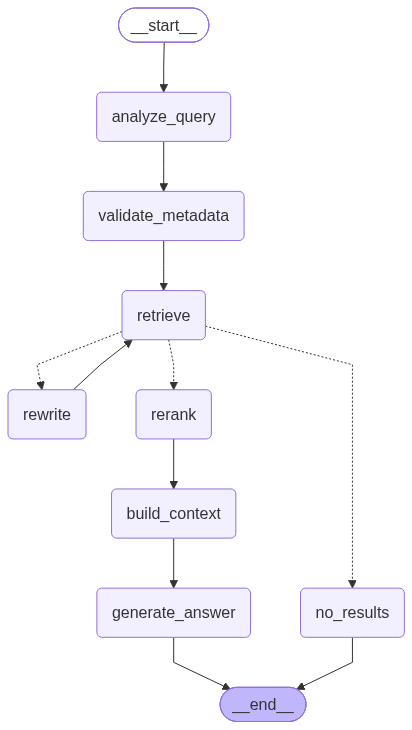

In [49]:
rag_graph